# 🏦 Loan Approval Prediction
### Cleaned & Improved Version
Dataset: `loan_approval_dataset.csv`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
import joblib

warnings.filterwarnings('ignore')
%matplotlib inline
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# Data loading
import pandas as pd
from pathlib import Path

data_path = Path("loan_approval_dataset .csv")

df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()
df.drop("loan_id", axis=1, inplace=True, errors="ignore")

print("Dataset loaded from:", data_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'loan_approval_dataset .csv'

## 2. Load Data

In [ ]:
df.tail()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [ ]:
print('Null Values:')
df.isnull().sum()

Null Values:


no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [ ]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## 3. Exploratory Data Analysis (EDA)

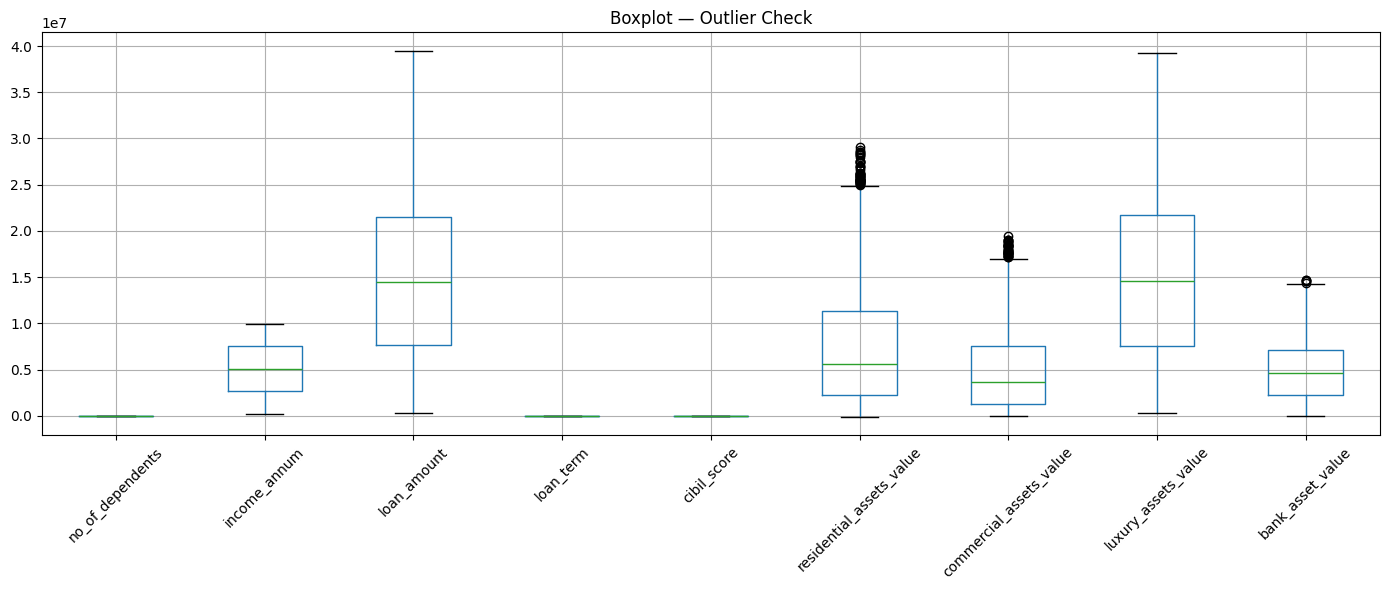

In [ ]:
# Boxplot — Outlier Check (numeric only)
plt.figure(figsize=(14, 6))
df.select_dtypes(include='number').boxplot()
plt.title('Boxplot — Outlier Check')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

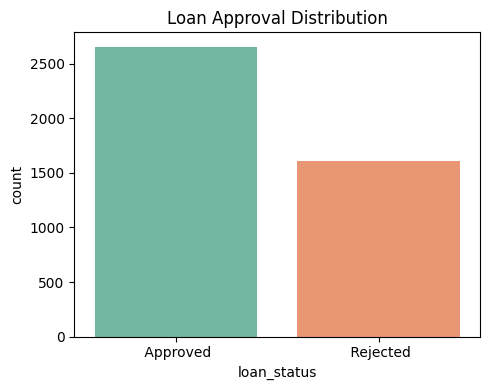

In [ ]:
# Target variable distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title('Loan Approval Distribution')
plt.tight_layout()
plt.show()

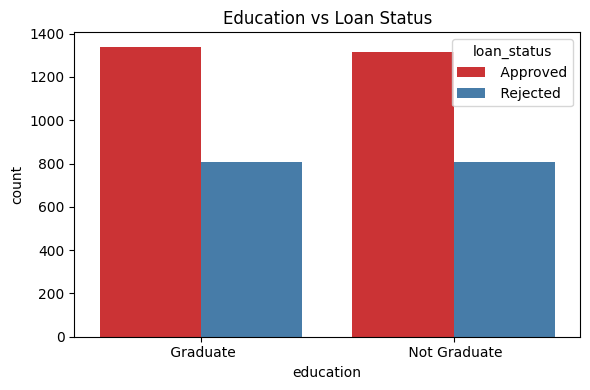

In [ ]:
# Education vs Loan Status
plt.figure(figsize=(6, 4))
sns.countplot(x='education', hue='loan_status', data=df, palette='Set1')
plt.title('Education vs Loan Status')
plt.tight_layout()
plt.show()

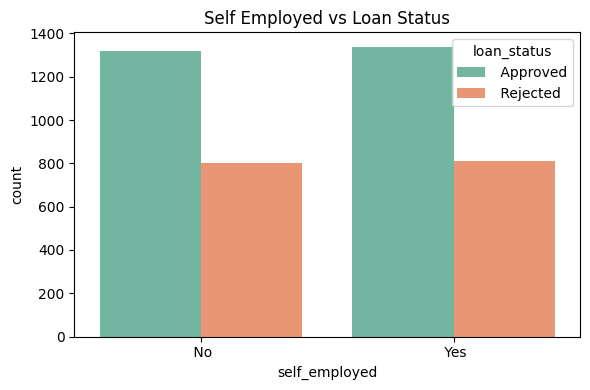

In [ ]:
# Self Employed vs Loan Status
plt.figure(figsize=(6, 4))
sns.countplot(x='self_employed', hue='loan_status', data=df, palette='Set2')
plt.title('Self Employed vs Loan Status')
plt.tight_layout()
plt.show()

## 4. Data Cleaning

In [ ]:
# Fill missing numeric values with median (robust against outliers)
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode + strip whitespace
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].fillna(df[col].mode()[0])

print('Null values after cleaning:', df.isnull().sum().sum())

Null values after cleaning: 0


## 5. Drop Irrelevant Column

In [ ]:
# luxury_assets_value: very high std, low correlation with target
if 'luxury_assets_value' in df.columns:
    df.drop('luxury_assets_value', axis=1, inplace=True)
    print('luxury_assets_value dropped ✅')
print('Remaining columns:', df.columns.tolist())

luxury_assets_value dropped ✅
Remaining columns: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'bank_asset_value', 'loan_status']


## 6. Feature Engineering

In [ ]:
# Feature Engineering — derived features
df['loan_income_ratio'] = df['loan_amount'] / df['income_annum']
df['emi_income_ratio']  = (df['loan_amount'] / 60) / df['income_annum']
df['income_per_person'] = df['income_annum'] / (df['no_of_dependents'] + 1)

# New engineered feature from asset columns
df['total_assets'] = (
    df['residential_assets_value']
    + df['commercial_assets_value']
    + df['bank_asset_value']
)

print('New features added:')
print('  loan_income_ratio ✅')
print('  emi_income_ratio  ✅')
print('  income_per_person ✅')
print('  total_assets      ✅')

df[['loan_income_ratio', 'emi_income_ratio', 'income_per_person', 'total_assets']].head()

New features added:
  loan_income_ratio ✅
  emi_income_ratio  ✅
  income_per_person ✅
  total_assets      ✅


,loan_income_ratio,emi_income_ratio,income_per_person,total_assets
0,3.114583,0.051910,3.200000e+06,28000000
1,2.975610,0.049593,4.100000e+06,8200000
2,3.263736,0.054396,2.275000e+06,24400000
3,3.743902,0.062398,2.050000e+06,29400000
4,2.469388,0.041156,1.633333e+06,25600000


## 7. Encoding Categorical Variables

In [ ]:
# Pehle strip karo spaces
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

# Ab encode karo
df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

print('Encoding done ✅')
print(df[['education', 'self_employed', 'loan_status']].head())

Encoding done ✅
   education  self_employed  loan_status
0          1              0            1
1          0              1            0
2          1              0            0
3          1              0            0
4          0              1            0


## 8. Correlation Heatmap

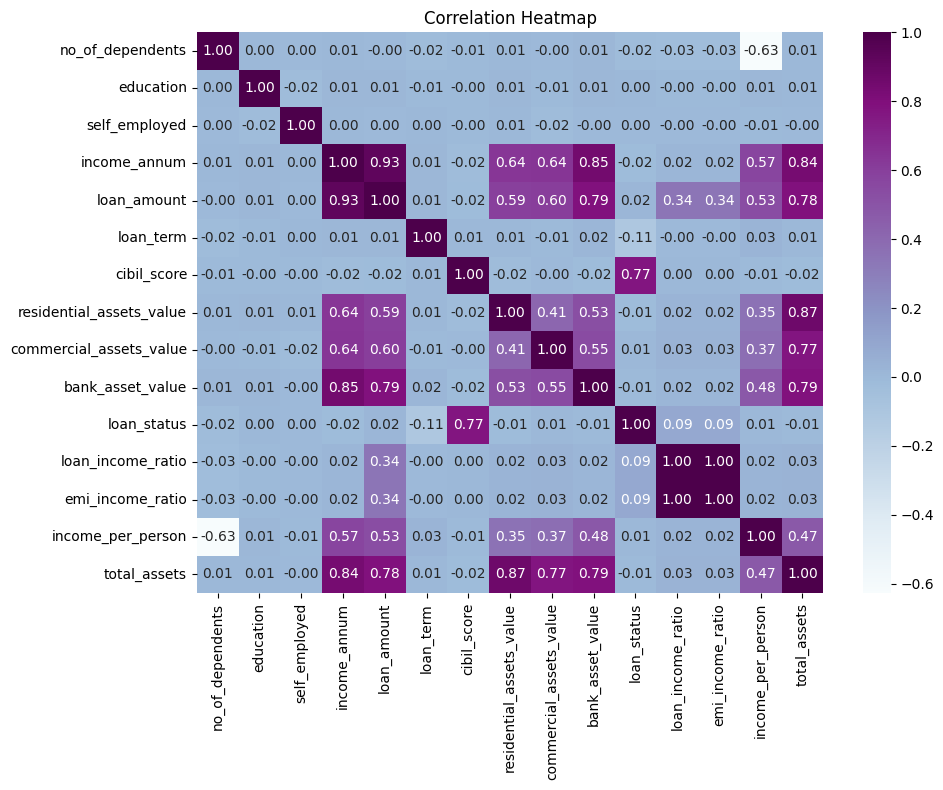

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='BuPu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 9. Train / Test Split

In [ ]:
FEATURES = [
    'no_of_dependents',
    'education',
    'self_employed',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'loan_income_ratio',
    'emi_income_ratio',
    'income_per_person',
    'total_assets'
]

X = df[FEATURES]
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Selected features:')
print(FEATURES)
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Train size: {X_train.shape}')
print(f'Test size:  {X_test.shape}')

Selected features:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'loan_income_ratio', 'emi_income_ratio', 'income_per_person', 'total_assets']
X shape: (4269, 11)
y shape: (4269,)
Train size: (3415, 11)
Test size:  (854, 11)


## 10. Train All 4 Models

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results[name] = {'model': model, 'accuracy': acc, 'roc_auc': auc, 'y_pred': y_pred}
    print(f'{name:25s} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}')

Logistic Regression       | Accuracy: 0.8560 | ROC-AUC: 0.9335
Decision Tree             | Accuracy: 0.9941 | ROC-AUC: 0.9929
Random Forest             | Accuracy: 0.9953 | ROC-AUC: 0.9993
KNN                       | Accuracy: 0.5644 | ROC-AUC: 0.4815


## 11. Detailed Evaluation — Classification Reports

In [ ]:
for name, res in results.items():
    print(f'\n{'='*45}')
    print(f'  {name}')
    print(f'{'='*45}')
    print(classification_report(y_test, res['y_pred'], target_names=['Rejected', 'Approved']))


  Logistic Regression
              precision    recall  f1-score   support

    Rejected       0.83      0.77      0.80       323
    Approved       0.87      0.91      0.89       531

    accuracy                           0.86       854
   macro avg       0.85      0.84      0.84       854
weighted avg       0.86      0.86      0.85       854


  Decision Tree
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       323
    Approved       0.99      1.00      1.00       531

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854


  Random Forest
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       323
    Approved       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      0.99      1.00       854
weighted avg     

## 12. Confusion Matrices

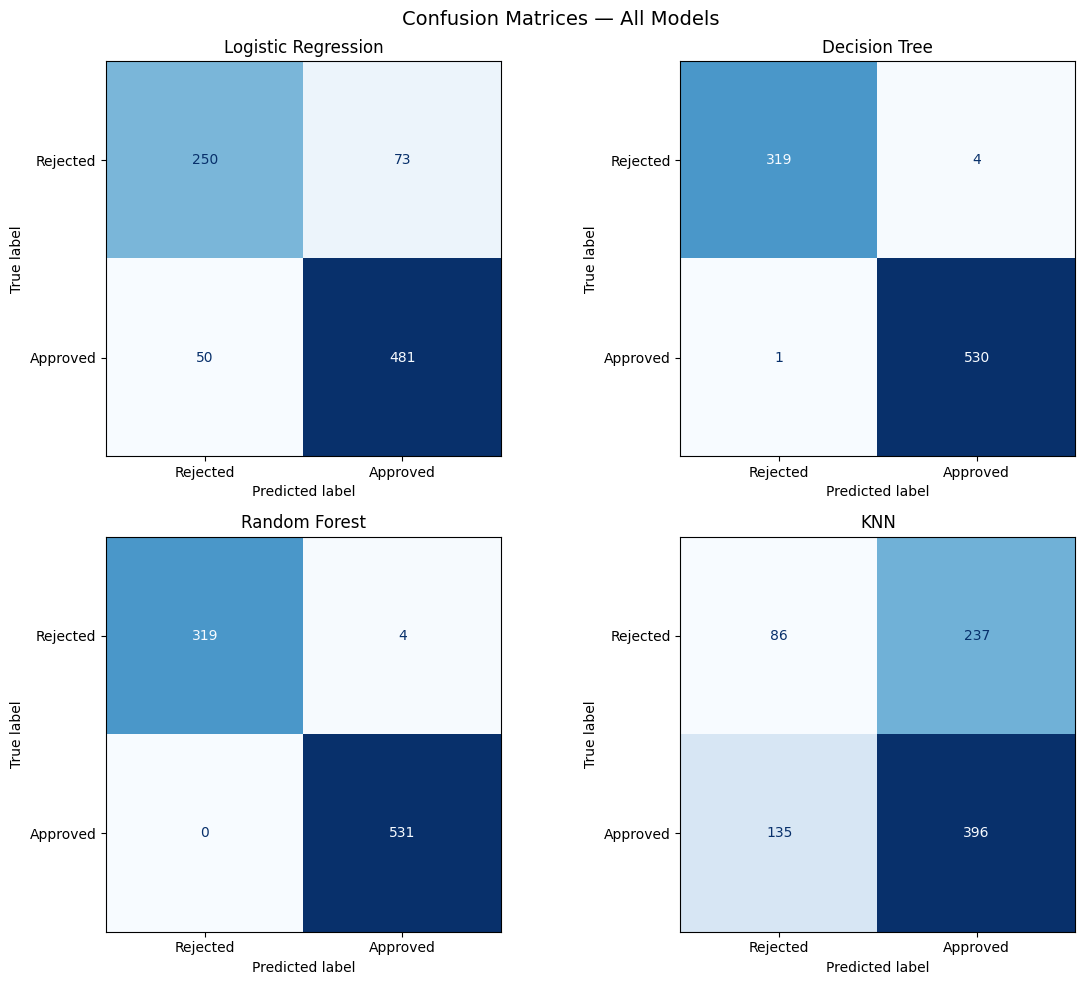

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

## 13. ROC Curves

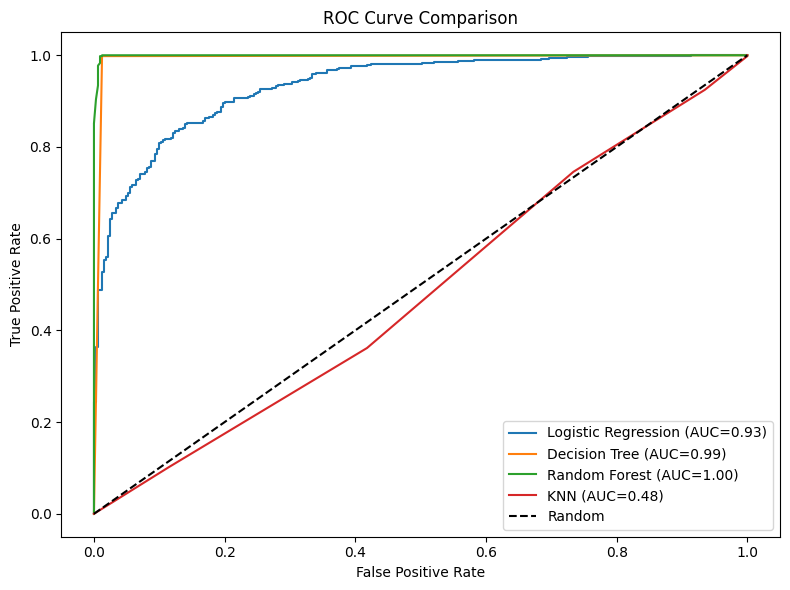

In [ ]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['model'].predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Model Comparison Chart

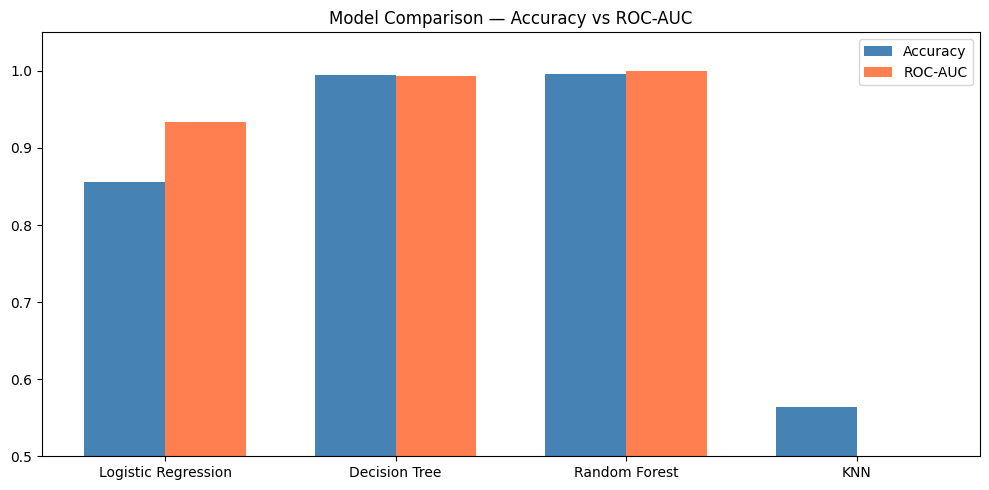

In [ ]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
aucs        = [results[m]['roc_auc']  for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, aucs,       width, label='ROC-AUC',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Comparison — Accuracy vs ROC-AUC')
ax.legend()
plt.tight_layout()
plt.show()

## 15. Save Best Model

In [ ]:
best_name  = max(results, key=lambda m: results[m]['roc_auc'])
best_model = results[best_name]['model']

print(f'✅ Best Model: {best_name}')
print(f'   Accuracy : {results[best_name]["accuracy"]:.4f}')
print(f'   ROC-AUC  : {results[best_name]["roc_auc"]:.4f}')

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(FEATURES,   'features.pkl')
print('\n💾 Saved: best_model.pkl & features.pkl')

✅ Best Model: Random Forest
   Accuracy : 0.9953
   ROC-AUC  : 0.9993

💾 Saved: best_model.pkl & features.pkl


## 16. Predict — Try It Yourself!

In [ ]:
def predict_loan(no_of_dependents, education, self_employed, income_annum,
                 loan_amount, loan_term, cibil_score,
                 residential_assets_value, commercial_assets_value,
                 luxury_assets_value, bank_asset_value):
    """
    Predict loan approval.
    education: 1=Graduate, 0=Not Graduate
    self_employed: 1=Yes, 0=No
    """
    loan_income_ratio = loan_amount / income_annum
    emi_income_ratio  = (loan_amount / 60) / income_annum
    income_per_person = income_annum / (no_of_dependents + 1)
    total_assets = (
        residential_assets_value
        + commercial_assets_value
        + luxury_assets_value
        + bank_asset_value
    )

    user_input = np.array([[
        no_of_dependents, education, self_employed, income_annum,
        loan_amount, loan_term, cibil_score,
        loan_income_ratio, emi_income_ratio, income_per_person, total_assets
    ]])

    prediction = best_model.predict(user_input)
    return 'Loan Approved ✅' if prediction[0] == 1 else 'Loan Rejected ❌'


# ✏️ Change these values to test different applicants
result = predict_loan(
    no_of_dependents         = 2,
    education                = 1,         # 1=Graduate, 0=Not Graduate
    self_employed            = 0,         # 1=Yes, 0=No
    income_annum             = 600000,    # ₹6 Lakh
    loan_amount              = 1500000,   # ₹15 Lakh
    loan_term                = 12,
    cibil_score              = 549,
    residential_assets_value = 400000,
    commercial_assets_value  = 150000,
    luxury_assets_value      = 250000,
    bank_asset_value         = 100000
)

print(f'Result → {result}')

NameError: name 'best_model' is not defined